In [1]:
#this is a generic code for looking at the continous HOBO data against the manual field measurements. Replace all of the "placeholders" with the files/parameters that you are looking for.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
 #install the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells

In [4]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [6]:
import os #allows python to communicate directly with the computer's operating system

In [7]:
# #reading P1 continuous data
# P1rawhobodf = pd.read_csv("P1_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv with the name of yoru csv with all the continuous hobo data
# #P1hobodf = P1rawhobodf.dropna()
# P1hobodf["Date-Time"] = pd.to_datetime(P1hobodf["Date-Time"]) #"Date-Time" is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
# P1rawdate = P1hobodf["Date-Time"] #this names the variable "date"
# P1hobodfdate = P1rawdate[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.
# date1 = P1rawdate.drop([36191])
# P1date = date1.drop(np.arange(36192, 36211))

In [8]:
# #reading the continuous data
hobodf = pd.read_csv("P1_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv is a placeholder for the name of your csv with all the continuous hobo data
hobodf = hobodf.dropna()
hobodf["Date-Time"] = pd.to_datetime(hobodf["Date-Time"]) #Date-Time (CST/CDT) is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
date = hobodf["Date-Time"] #this names the variable "date"
sliceddate = date[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.
date1 = sliceddate.drop([36191])
date2 = date1.drop(np.arange(36192, 36211))

In [9]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
hampelhobo = hampel(hobodf["Temp"], window_size=6, n_sigma=1.5) #filtering the data: for every point, a window of six data points on either side is applied, and the point is comparted to the median absolute deviation (with 1.5 standard deviations). If the data falls outside the MAD, it is counted as an outlier and removed. Temperature (W-CT 22414702), °C is a placeholder for the name of the column with the parameter of interest. filteredhobo is a placeholder.
filteredhoboseries = pd.Series(hampelhobo.filtered_data, index = hobodf.index) #the hampel filter changes the type of data, and this forces it back into a panda series. filteredhoboseries is a placeholder. 
filteredhobo1 = filteredhoboseries[1:] #the hampel filter cannot remove the first data point (which I think is padded by zeroes), so I manually sliced it off. The variable is rewritten here to be called filteredhobo, which, after running this cell should be the continuous data without the spikes, forced back into a series, with the first data point removed. 
# filteredhobo = filteredhobo1.pop(36213)
filteredhobo2 = filteredhobo1.drop([36191])
filteredhobo = filteredhobo2.drop(np.arange(36192, 36211))

In [10]:
#reading P2 continuous data
P2hobodf = pd.read_csv("P2_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv with the name of yoru csv with all the continuous hobo data
P2hobodf["Date-Time"] = pd.to_datetime(P2hobodf["Date-Time"]) #"Date-Time" is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
P2date = P2hobodf["Date-Time"] #this names the variable "date"
P2hobodfdate = P2date[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.


In [11]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
P2filteredhobo = hampel(P2hobodf["Temperature"], window_size=6, n_sigma=1.5) #filtering the data: for every point, a window of six data points on either side is applied, and the point is comparted to the median absolute deviation (with 1.5 standard deviations). If the data falls outside the MAD, it is counted as an outlier and removed. filteredhobo is a placeholder.
P2filteredhoboseries = pd.Series(P2filteredhobo.filtered_data, index = P2hobodf.index) #the hampel filter changes the type of data, and this forces it back into a panda series. filteredhoboseries is a placeholder. 
P2filteredhobo = P2filteredhoboseries[1:] #the hampel filter cannot remove the first data point (which I think is padded by zeroes), so I manually sliced it off. The variable is rewritten here to be called filteredhobo, which, after running this cell should be the continuous data without the spikes, forced back into a series, with the first data point removed. 


In [12]:
#reading P3 continuous data
P3hobodf = pd.read_csv("P3_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv with the name of yoru csv with all the continuous hobo data
P3hobodf["Date-Time"] = pd.to_datetime(P3hobodf["Date-Time"]) #"Date-Time" is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
P3date = P3hobodf["Date-Time"] #this names the variable "date"
P3hobodfdate = P3date[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.

In [13]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
P3filteredhobo = hampel(P3hobodf["Temperature"], window_size=6, n_sigma=1.5) #filtering the data: for every point, a window of six data points on either side is applied, and the point is comparted to the median absolute deviation (with 1.5 standard deviations). If the data falls outside the MAD, it is counted as an outlier and removed. filteredhobo is a placeholder.
P3filteredhoboseries = pd.Series(P3filteredhobo.filtered_data, index = P3hobodf.index) #the hampel filter changes the type of data, and this forces it back into a panda series. filteredhoboseries is a placeholder. 
P3filteredhobo = P3filteredhoboseries[1:] #the hampel filter cannot remove the first data point (which I think is padded by zeroes), so I manually sliced it off. The variable is rewritten here to be called filteredhobo, which, after running this cell should be the continuous data without the spikes, forced back into a series, with the first data point removed. 


In [14]:
#reading P4 continuous data
P4hobodf = pd.read_csv("P4_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv with the name of yoru csv with all the continuous hobo data
P4hobodf["Date-Time"] = pd.to_datetime(P4hobodf["Date-Time"]) #"Date-Time" is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
P4date = P4hobodf["Date-Time"] #this names the variable "date"
P4hobodfdate = P4date[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.

In [15]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
P4filteredhobo = hampel(P4hobodf["Temperature"], window_size=6, n_sigma=1.5) #filtering the data: for every point, a window of six data points on either side is applied, and the point is comparted to the median absolute deviation (with 1.5 standard deviations). If the data falls outside the MAD, it is counted as an outlier and removed. filteredhobo is a placeholder.
P4filteredhoboseries = pd.Series(P4filteredhobo.filtered_data, index = P4hobodf.index) #the hampel filter changes the type of data, and this forces it back into a panda series. filteredhoboseries is a placeholder. 
P4filteredhobo = P4filteredhoboseries[1:] #the hampel filter cannot remove the first data point (which I think is padded by zeroes), so I manually sliced it off. The variable is rewritten here to be called filteredhobo, which, after running this cell should be the continuous data without the spikes, forced back into a series, with the first data point removed. 


In [16]:
#reading P5 continuous data
P5hobodf = pd.read_csv("P5_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv with the name of yoru csv with all the continuous hobo data
P5hobodf["Date-Time"] = pd.to_datetime(P5hobodf["Date-Time"]) #"Date-Time" is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
P5date = P5hobodf["Date-Time"] #this names the variable "date"
P5hobodfdate = P5date[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.

In [17]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
P5filteredhobo = hampel(P5hobodf["Temperature"], window_size=6, n_sigma=1.5) #filtering the data: for every point, a window of six data points on either side is applied, and the point is comparted to the median absolute deviation (with 1.5 standard deviations). If the data falls outside the MAD, it is counted as an outlier and removed. filteredhobo is a placeholder.
P5filteredhoboseries = pd.Series(P5filteredhobo.filtered_data, index = P5hobodf.index) #the hampel filter changes the type of data, and this forces it back into a panda series. filteredhoboseries is a placeholder. 
P5filteredhobo = P5filteredhoboseries[1:] #the hampel filter cannot remove the first data point (which I think is padded by zeroes), so I manually sliced it off. The variable is rewritten here to be called filteredhobo, which, after running this cell should be the continuous data without the spikes, forced back into a series, with the first data point removed. 


In [18]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDam2.csv") #"NOAAHastingsDam2.csv" is a placeholder for the csv with your weather data
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])


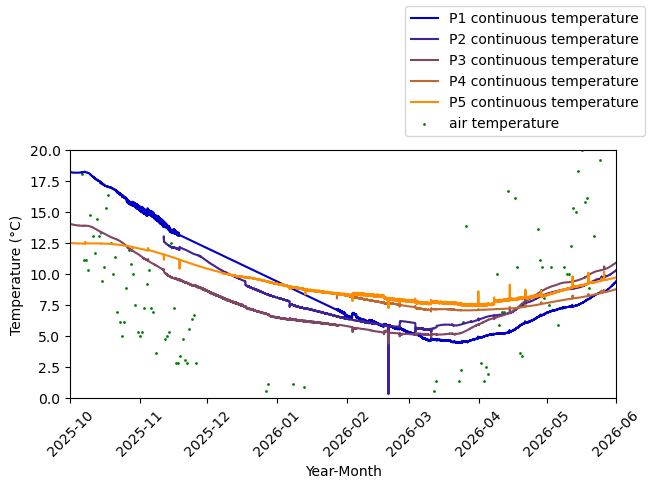

In [19]:

fig, ax = plt.subplots(layout='constrained')
ax.plot(date2, filteredhobo, color="#0200C6", label = "P1 continuous temperature")
ax.plot(P2hobodfdate, P2filteredhobo, color="#412395", label = "P2 continuous temperature")
ax.plot(P3hobodfdate, P3filteredhobo, color="#814663", label = "P3 continuous temperature")
ax.plot(P4hobodfdate, P4filteredhobo, color="#C06832", label = "P4 continuous temperature")
ax.plot(P5hobodfdate, P5filteredhobo, color="#FF8B00", label = "P5 continuous temperature")
ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature") #the air temperature data
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.
plt.ylim((0, 20))
plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))


#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

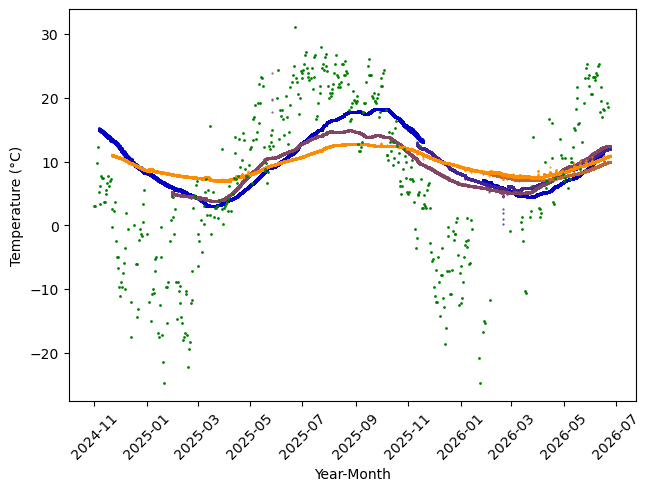

In [20]:
fig, ax = plt.subplots(layout='constrained')
ax.scatter(date2, filteredhobo, s = 1, color="#0200C6", label = "P1 continuous temperature")
ax.scatter(P2hobodfdate, P2filteredhobo, s = 0.25, color="#412395", label = "P2 continuous temperature")
ax.scatter(P3hobodfdate, P3filteredhobo, s = 0.25, color="#814663", label = "P3 continuous temperature")
ax.scatter(P4hobodfdate, P4filteredhobo, s = 0.25, color="#C06832", label = "P4 continuous temperature")
ax.scatter(P5hobodfdate, P5filteredhobo, s = 0.25, color="#FF8B00", label = "P5 continuous temperature")
ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature") #the air temperature data
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.
# plt.ylim((0, 20))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))

# fig.legend(loc='outside upper right')

plt.show()

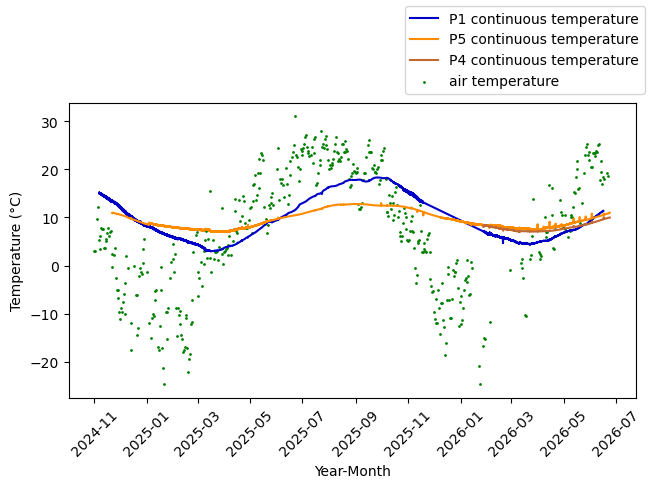

In [21]:
fig, ax = plt.subplots(layout='constrained')
ax.plot(date2, filteredhobo, color="#0200C6", label = "P1 continuous temperature")
ax.plot(P5hobodfdate, P5filteredhobo, color="#FF8B00", label = "P5 continuous temperature")
ax.plot(P4hobodfdate, P4filteredhobo, color="#C06832", label = "P4 continuous temperature")
ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature") #the air temperature data

plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.
# plt.ylim((0, 20))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))

fig.legend(loc='outside upper right')

plt.show()